In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime 
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


# The data is csv in a single column, then:
df = pd.read_csv('/home/asabele/Downloads/Documents/My Data Science Practise/Unemployment in India.csv', sep=',')

print("Dataset Shape:", df.shape)
print("Column Names:")
print(df.columns.tolist())
print("First 10 rows:")
print(df.head(10))

print("\nUnique Regions:", df['Region'].nunique())
print("\nUnique Areas:", df['Area'].unique())

Dataset Shape: (768, 7)
Column Names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']
First 10 rows:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   
5  Andhra Pradesh   31-10-2019    Monthly                              3.52   
6  Andhra Pradesh   30-11-2019    Monthly                              4.12   
7  Andhra Pradesh   31-12-2019    Monthly                              4.38   
8  Andhra Pradesh   31-01-2020    Monthly                              4.84   
9  Andhra Pr

In [15]:
df.columns = df.columns.str.strip()

#I Check where the NaNs are
print("Missing values per column:", df.isnull().sum())

#Drop rows where all elements are missing
df = df.dropna(how='all')

# For 'Area', since it's categorical, we can drop rows with missing Area 
# or fill them if we can infer them. Here, dropping is safest.
df = df.dropna(subset=['Area'])

print(f"New Shape after dropping NaNs: {df.shape}")

Missing values per column: Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64
New Shape after dropping NaNs: (740, 7)


In [16]:
# 1. Clean column names again to match your plotting code
# Turning "Estimated Unemployment Rate (%)" -> "Estimated_Unemployment_Rate"
df.columns = [c.strip().replace(' ', '_').replace('(%)', '').replace('__', '_').rstrip('_') for c in df.columns]

# 2. Convert Date and create 'Month_Year' and 'Period'
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')
df['Month_Year'] = df['Date'].dt.to_period('M')

# 3. Create the 'Period' column based on the COVID-19 lockdown in India (March 2020)
df['Period'] = df['Date'].apply(lambda x: 'COVID' if x >= pd.Timestamp('2020-03-01') else 'Pre-COVID')

print("New Columns Available:", df.columns.tolist())


New Columns Available: ['Region', 'Date', 'Frequency', 'Estimated_Unemployment_Rate', 'Estimated_Employed', 'Estimated_Labour_Participation_Rate', 'Area', 'Month_Year', 'Period']


Model trained, R2 Score: 0.66
Model R2 Score: 0.6639
Mean Absolute Error: 3.52%


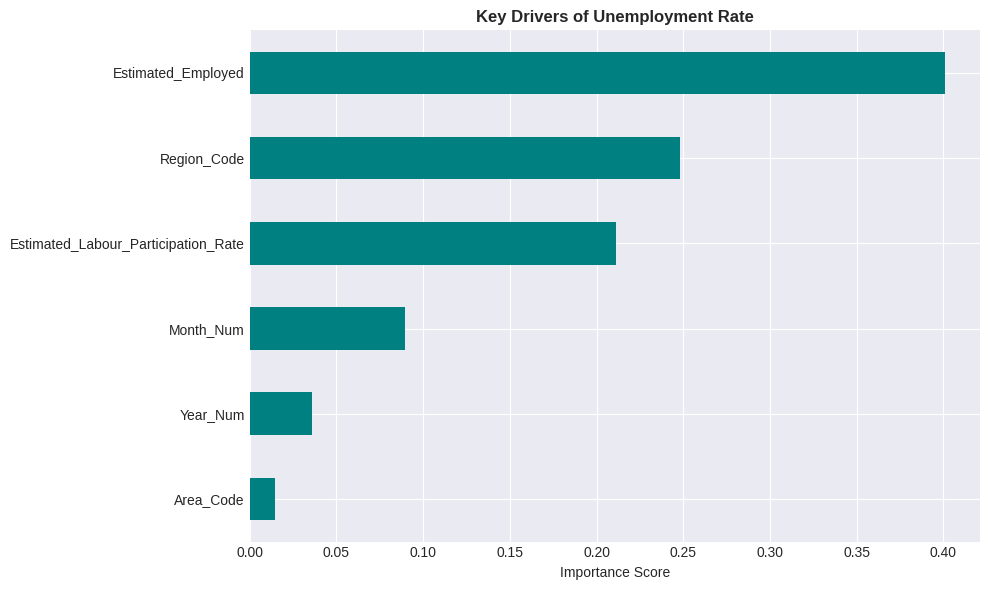

Analysis Complete!


In [24]:
# Create a copy for ML
ml_df = df.copy().dropna()

# Encode Categorical Variables
le = LabelEncoder()
ml_df['Region_Code'] = le.fit_transform(ml_df['Region'])
ml_df['Area_Code'] = le.fit_transform(ml_df['Area'])

# Extract month and year as numerical features
ml_df['Month_Num'] = ml_df['Date'].dt.month
ml_df['Year_Num'] = ml_df['Date'].dt.year

# Define Features (X) and Target (y)
# We want to predict the Rate using Region, Area, Month, and Employment numbers
features = ['Region_Code', 'Area_Code', 'Month_Num', 'Year_Num', 
            'Estimated_Employed', 'Estimated_Labour_Participation_Rate']
X = ml_df[features]
y = ml_df['Estimated_Unemployment_Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1000)

# Train Random Forest (best for non-linear spikes like COVID)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print(f"Model trained, R2 Score: {rf_model.score(X_test, y_test):.2f}")

# 5. EVALUATE & VISUALIZE
predictions = rf_model.predict(X_test)
print(f"Model R2 Score: {r2_score(y_test, predictions):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.2f}%")

# Plot Feature Importance
plt.figure(figsize=(10, 6))
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', color='teal')
plt.title('Key Drivers of Unemployment Rate', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Analysis Complete!")

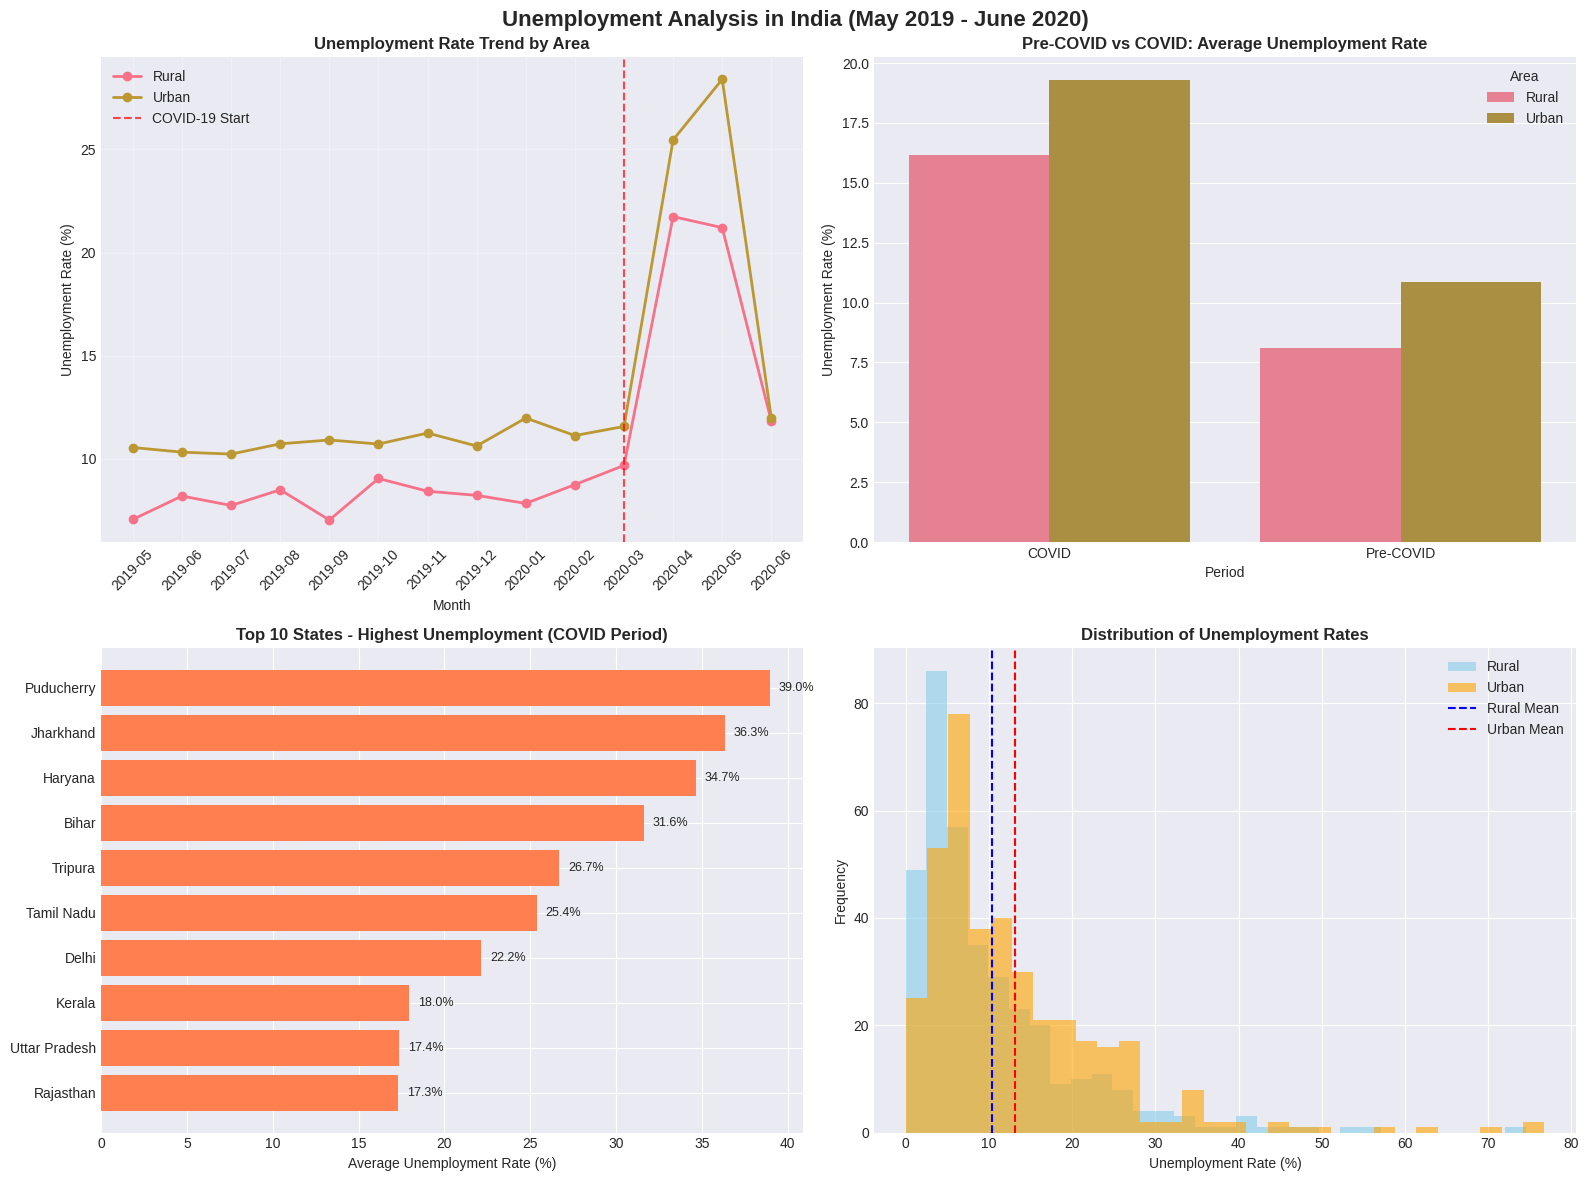

In [28]:
# 1. Prepare the columns to match your plotting code
df.columns = [c.strip().replace(' ', '_').replace('(%)', '').replace('__', '_').rstrip('_') for c in df.columns]

# 2. Ensure Date and Month_Year are set up for Plot 1
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'].astype(str).str.strip(), format='%d-%m-%Y')

# Now create Month_Year (this uses the .dt accessor)
df['Month_Year'] = df['Date'].dt.to_period('M')

# 3. Ensure the 'Period' column is set up for Plot 2 & 3
df['Period'] = df['Date'].apply(lambda x: 'COVID' if x >= pd.Timestamp('2020-03-01') else 'Pre-COVID')

# --- NOW START YOUR VISUALIZATION ---
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Unemployment Analysis in India (May 2019 - June 2020)', fontsize=16, fontweight='bold')

# Plot 1: Monthly trend by Area (Rural vs Urban)
monthly_trend = df.groupby(['Month_Year', 'Area'])['Estimated_Unemployment_Rate'].mean().reset_index()
monthly_trend['Month_Year'] = monthly_trend['Month_Year'].astype(str)

ax1 = axes[0, 0]
for area in ['Rural', 'Urban']:
    data = monthly_trend[monthly_trend['Area'] == area]
    ax1.plot(data['Month_Year'], data['Estimated_Unemployment_Rate'], 
             marker='o', linewidth=2, label=area, markersize=6)

ax1.axvline(x='2020-03', color='red', linestyle='--', alpha=0.7, label='COVID-19 Start')
ax1.set_title('Unemployment Rate Trend by Area', fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Unemployment Rate (%)')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Plot 2: Pre-COVID vs COVID comparison
period_comparison = df.groupby(['Period', 'Area'])['Estimated_Unemployment_Rate'].mean().reset_index()
ax2 = axes[0, 1]
sns.barplot(data=period_comparison, x='Period', y='Estimated_Unemployment_Rate', hue='Area', ax=ax2)
ax2.set_title('Pre-COVID vs COVID: Average Unemployment Rate', fontweight='bold')
ax2.set_ylabel('Unemployment Rate (%)')
ax2.legend(title='Area')

# Plot 3: Top 10 states with highest unemployment during COVID
covid_data = df[df['Period'] == 'COVID']
state_covid = covid_data.groupby('Region')['Estimated_Unemployment_Rate'].mean().sort_values(ascending=False).head(10)
ax3 = axes[1, 0]
bars = ax3.barh(range(len(state_covid)), state_covid.values, color='coral')
ax3.set_yticks(range(len(state_covid)))
ax3.set_yticklabels(state_covid.index)
ax3.set_xlabel('Average Unemployment Rate (%)')
ax3.set_title('Top 10 States - Highest Unemployment (COVID Period)', fontweight='bold')
ax3.invert_yaxis()
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', ha='left', va='center', fontsize=9)

# Plot 4: Distribution of unemployment rates
ax4 = axes[1, 1]
df[df['Area'] == 'Rural']['Estimated_Unemployment_Rate'].hist(
    bins=30, alpha=0.6, label='Rural', ax=ax4, color='skyblue')
df[df['Area'] == 'Urban']['Estimated_Unemployment_Rate'].hist(
    bins=30, alpha=0.6, label='Urban', ax=ax4, color='orange')
ax4.axvline(df[df['Area'] == 'Rural']['Estimated_Unemployment_Rate'].mean(), 
            color='blue', linestyle='--', label='Rural Mean')
ax4.axvline(df[df['Area'] == 'Urban']['Estimated_Unemployment_Rate'].mean(), 
            color='red', linestyle='--', label='Urban Mean')
ax4.set_title('Distribution of Unemployment Rates', fontweight='bold')
ax4.set_xlabel('Unemployment Rate (%)')
ax4.set_ylabel('Frequency')
ax4.legend()

plt.tight_layout()
plt.show()
